In [1]:
import torch
import shutil
import os
import time


from CFD.Riemann_Solvers_and_Numerical_Methods_for_Fluid_Dynamics_by_TORO.chapter13_14 import muscl_reconstruction, transmissive_bc, reflective_bc
from CFD.Riemann_Solvers_and_Numerical_Methods_for_Fluid_Dynamics_by_TORO.chapter16 import strang_update
from CFD.Riemann_Solvers_and_Numerical_Methods_for_Fluid_Dynamics_by_TORO.chapter10 import HLLC_Riemann_Solver
from CFD import Simulator
from CFD import create_explosion_initial_condition

from CFD import LinesOnVolume, create_random_sphere_points, create_uniform_sphere_points

from CFD import generate_multiband_smooth_noise_fft

from JupyterVisualizer import visualize_voxel, ImageVisualizer, visualize_point_cloud

from util import create_boundary_band_solid_mask, create_sphere_solid_mask

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

folder = "/TMP_MOUNT/cells"
folder_full = "/TMP_MOUNT/cells_full"

shutil.rmtree(folder, ignore_errors=True)
os.makedirs(folder, exist_ok=True)


Using device: cuda
CUDA device: NVIDIA GeForce RTX 5080


In [2]:
#PARAMETERS-----------------------------------------------------

#physical quantities--------------------------------------------

X_DOMAIN = [0, 1] # 1 m
Y_DOMAIN = [0, 1] # 1 m
Z_DOMAIN = [0, 1] # 1 m
T_DOMAIN = [0, 1]
EXPLOSION_T = 0.15

GAMMA = 1.4

#simulation parameters--------------------------------------------
#z, y, x
#for 2dim simulateion set z_domain to 1
DIMENSION = 3

RESOLUTION = 100, 100, 100

DX = (X_DOMAIN[1] - X_DOMAIN[0]) / RESOLUTION[2]
DY = (Y_DOMAIN[1] - Y_DOMAIN[0]) / RESOLUTION[1]
DZ = (Z_DOMAIN[1] - Z_DOMAIN[0]) / RESOLUTION[0]

CFL_COEFFICIENT = 0.6
TOL = 1e-6

#explosion parameters--------------------------------------------

# reference unit
rho0 = 1.2
p0   = 1e5
u0 = (p0 / rho0)**0.5

# Initial Conditions
rho_inner_phy = 3 #(kg/m³)
p_inner_phy = 1e7 #(pa)
rho_outer_phy = 1.225 #(kg/m³)
p_outer_phy = 101325 #(pa)

# convert to reference unit
rho_inner = rho_inner_phy / rho0
p_inner = p_inner_phy / p0
rho_outer = rho_outer_phy / rho0
p_outer = p_outer_phy / p0

sigma = 0.01
boundary_band_radius = 0.1

#lines on volume parameters----------------------------------------

num_polylines = 100

#num_points = 200
num_points = 100

In [3]:
CELL = create_explosion_initial_condition(
    RESOLUTION,
    x_domain = X_DOMAIN,
    y_domain = Y_DOMAIN,
    z_domain = Z_DOMAIN,
    explosion_center = (2 * DX, 2 * DY, 2 * DZ),
    rho_inner = rho_inner,
    p_inner = p_inner,
    rho_outer = rho_outer,
    p_outer = p_outer,
    sigma = sigma,
    noise = 0,
    r_k0_list   = [],
    weight_list = [],
    device = device
)

source = CELL.clone()

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-20 15:00:43.551 (   0.887s) [    794D73752740] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x437d4940): EGL device index: 0 could not be initialized. Trying other devices...


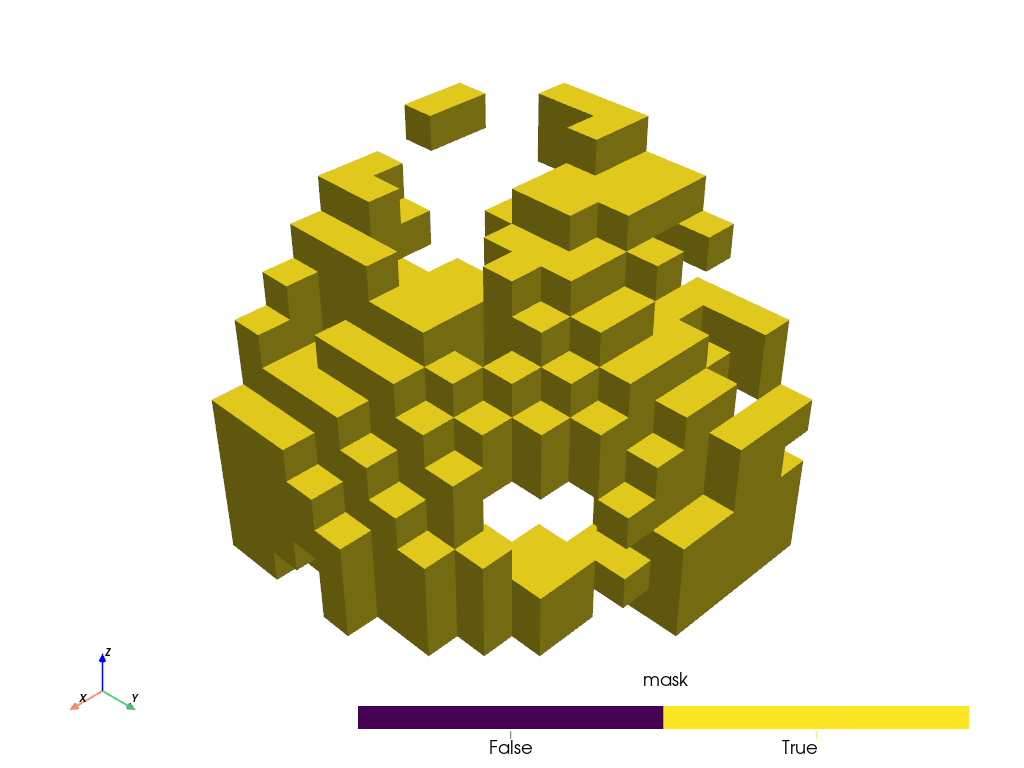

In [4]:
sphere = create_sphere_solid_mask(RESOLUTION, center = (0, 0, 0), radius = max(RESOLUTION) - 3)

boundary_band = create_boundary_band_solid_mask(
    RESOLUTION, 0.05, 0.4, boundary_band_radius, DX, DY, DZ, center = (0, 0, 0)
)
#radom_solid_cell = torch.rand(RESOLUTION, device=device) < 0.005

solid_cell = boundary_band | sphere

visualize_voxel(boundary_band)

In [5]:
'''
lines = create_random_sphere_points(
    boundary_band_radius,
    num_polylines,
    num_points,
    X_DOMAIN,
    Y_DOMAIN,
    Z_DOMAIN,
    device
)

# lines: (num_polylines, num_points, 4)
# 첫 번째 점의 xyz만 사용
first_points = lines[:, 0, :3]   # (num_polylines, 3)

# domain에서 voxel index로 변환
# 가정:
# X_DOMAIN = (x_min, x_max), Y_DOMAIN = (y_min, y_max), Z_DOMAIN = (z_min, z_max)
x_min, _ = X_DOMAIN
y_min, _ = Y_DOMAIN
z_min, _ = Z_DOMAIN

ix = ((first_points[:, 0] - x_min) / DX).long()
iy = ((first_points[:, 1] - y_min) / DY).long()
iz = ((first_points[:, 2] - z_min) / DZ).long()

# index 범위 보호
ix = torch.clamp(ix, 0, RESOLUTION[0] - 1)
iy = torch.clamp(iy, 0, RESOLUTION[1] - 1)
iz = torch.clamp(iz, 0, RESOLUTION[2] - 1)

# boundary_band 위에 있는 polyline 제거
# boundary_band가 bool tensor든 0/1 tensor든 동작 가능
keep_mask = boundary_band[iz, iy, ix] == 0

lines = lines[keep_mask]


lines = LinesOnVolume(2000, 2000, lines)


point_cloud = lines.lines[:, 0, :3].clone()

point_cloud[:, 0] *= RESOLUTION[0]
point_cloud[:, 1] *= RESOLUTION[1]
point_cloud[:, 2] *= RESOLUTION[2]

visualize_point_cloud(point_cloud, save_path = "./point_cloud.mp4")
'''


'\nlines = create_random_sphere_points(\n    boundary_band_radius,\n    num_polylines,\n    num_points,\n    X_DOMAIN,\n    Y_DOMAIN,\n    Z_DOMAIN,\n    device\n)\n\n# lines: (num_polylines, num_points, 4)\n# 첫 번째 점의 xyz만 사용\nfirst_points = lines[:, 0, :3]   # (num_polylines, 3)\n\n# domain에서 voxel index로 변환\n# 가정:\n# X_DOMAIN = (x_min, x_max), Y_DOMAIN = (y_min, y_max), Z_DOMAIN = (z_min, z_max)\nx_min, _ = X_DOMAIN\ny_min, _ = Y_DOMAIN\nz_min, _ = Z_DOMAIN\n\nix = ((first_points[:, 0] - x_min) / DX).long()\niy = ((first_points[:, 1] - y_min) / DY).long()\niz = ((first_points[:, 2] - z_min) / DZ).long()\n\n# index 범위 보호\nix = torch.clamp(ix, 0, RESOLUTION[0] - 1)\niy = torch.clamp(iy, 0, RESOLUTION[1] - 1)\niz = torch.clamp(iz, 0, RESOLUTION[2] - 1)\n\n# boundary_band 위에 있는 polyline 제거\n# boundary_band가 bool tensor든 0/1 tensor든 동작 가능\nkeep_mask = boundary_band[iz, iy, ix] == 0\n\nlines = lines[keep_mask]\n\n\nlines = LinesOnVolume(2000, 2000, lines)\n\n\npoint_cloud = lines.lines[:, 

In [6]:
sim = Simulator(
    CELL,
    dx=DX,
    dy=DY,
    dz=DZ,
    riemann_solver=HLLC_Riemann_Solver,
    reconstruction_method=muscl_reconstruction,
    boundary_function=reflective_bc,
    update_method=strang_update,
    solid_cell = solid_cell,
    dimension=DIMENSION,
    visualizers=[]
)

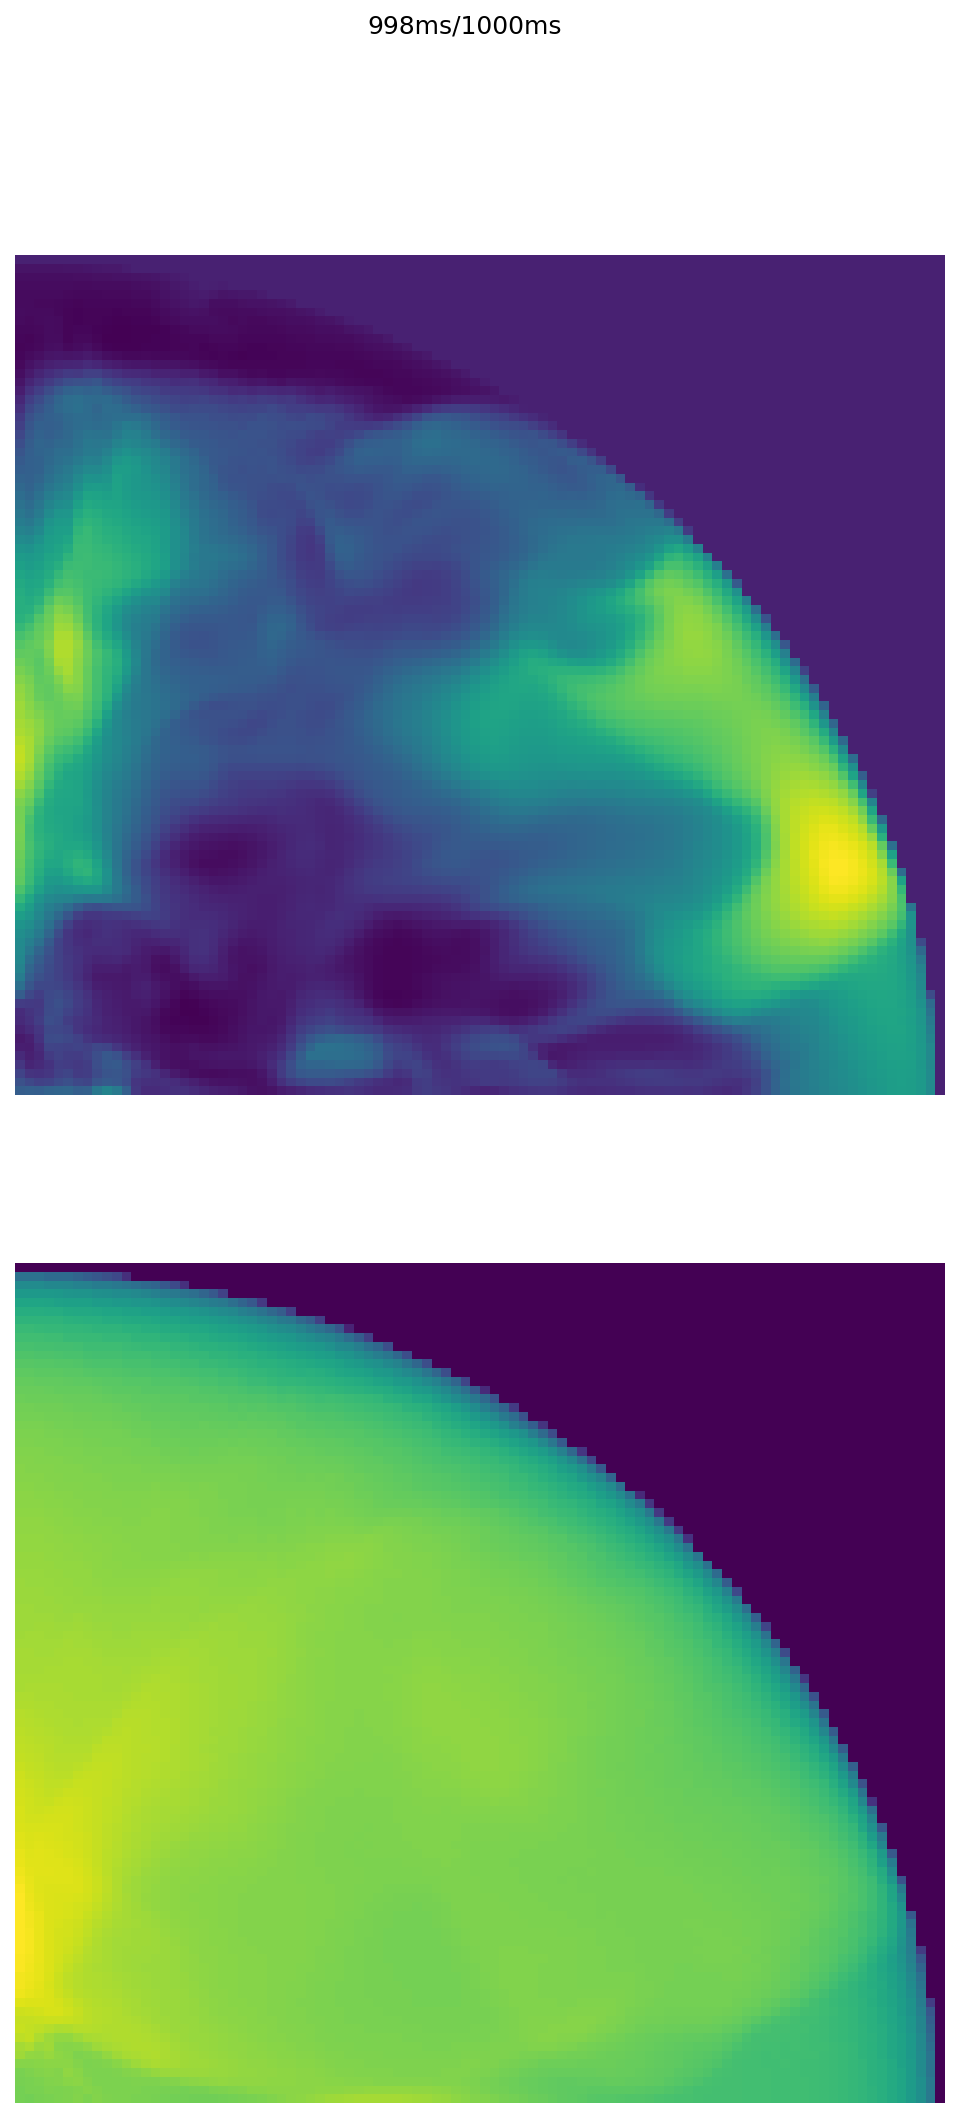

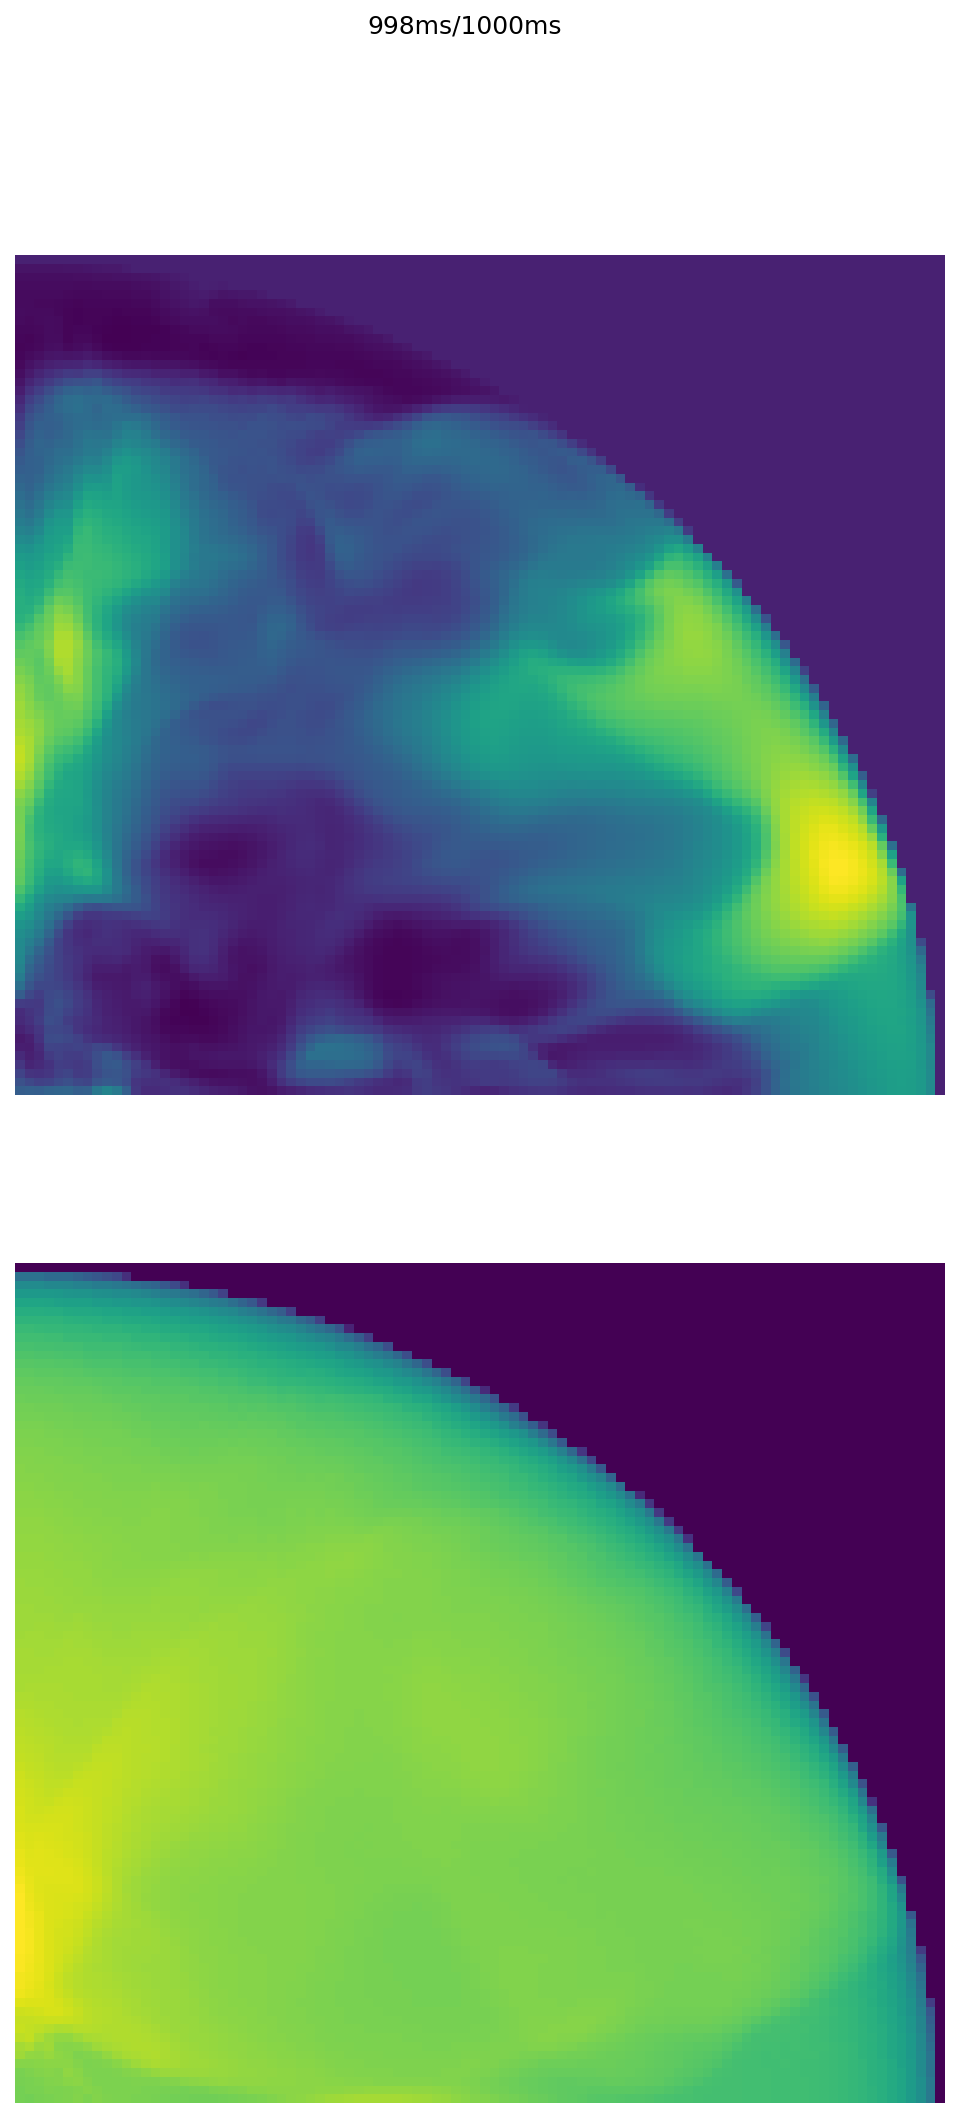

In [7]:
t = T_DOMAIN[0]
counter = 0

dt_record = []

IV = ImageVisualizer((sim.get_images_num(), 1), record = True, save_path="./run", figsize=(8, 8 * sim.get_images_num()), cmaps = [None, None, None])
IV.update(sim.get_images(), t)

while t < T_DOMAIN[1]:
    counter += 1
    dt = sim.update()
    t += dt
    dt_record.append(dt)

    if(t < EXPLOSION_T):
        sim.cell[..., 0] = torch.max(sim.cell[..., 0], source[..., 0])
        sim.cell[..., 4] = torch.max(sim.cell[..., 4], source[..., 4])
        
    if(counter % 3 == 0):
        IV.set_title(f"{round(t.item() * 1000)}ms/{T_DOMAIN[1] * 1000}ms")
        IV.update(sim.get_images(), t.item())

In [8]:
IV.close(PB_speed=0.1)

ffmpeg version 4.4.2 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 12.3.0 (conda-forge gcc 12.3.0-2)
  configuration: --prefix=/home/ty/anaconda3/envs/torch --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1697113881276/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1697113881276/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1697113881276/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1697113881276/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --disable-openssl --enable-avresample --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libfontconfig --enable-libopenh264 --enable-gnutls --enable-libmp3lame --enable-libvpx --enable-pthreads --enable-vaapi --enable-gpl --enable-libx264 --enable-libx265 --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --disa